# TP 1 — HOG + classifieur : solution commentée

Solution complète du [TP 1](./enonce.ipynb).

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure
from skimage.feature import hog
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

faces = fetch_olivetti_faces(shuffle=True, random_state=0)
images, y = faces.images, faces.target
print(images.shape, y.shape)

(400, 64, 64) (400,)


## Exercice 1 — Visualiser un HOG

shape descripteur : (1764,)


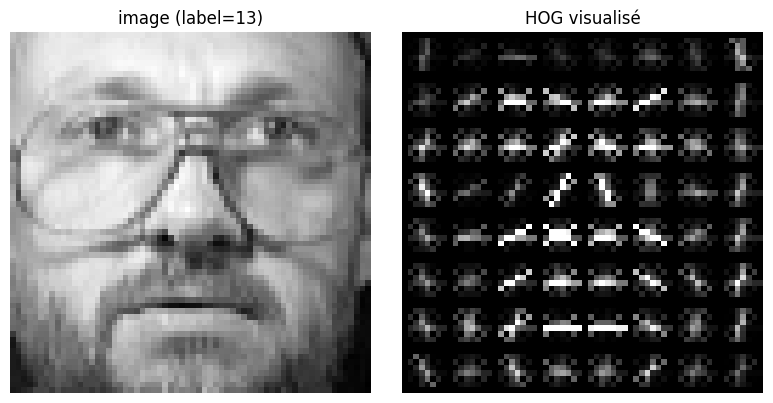

In [6]:
img = images[0]
desc, hog_img = hog(
    img,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
)
hog_disp = exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max() * 0.5))
print("shape descripteur :", desc.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"image (label={y[0]})")
axes[0].axis("off")
axes[1].imshow(hog_disp, cmap="gray")
axes[1].set_title("HOG visualisé")
axes[1].axis("off")
plt.tight_layout()

## Exercice 2 — Pixels vs HOG

In [3]:
X_pixels = images.reshape(len(images), -1)
X_hog = np.array(
    [
        hog(im, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm="L2-Hys")
        for im in images
    ]
)
print("X_pixels :", X_pixels.shape, "  X_hog :", X_hog.shape)


def evaluate(X):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
    clf = Pipeline([("sc", StandardScaler()), ("svm", LinearSVC(C=1.0, max_iter=5000))])
    clf.fit(Xtr, ytr)
    return clf.score(Xte, yte)


acc_pixels = evaluate(X_pixels)
acc_hog = evaluate(X_hog)
print(f"pixels bruts : {acc_pixels:.3f}")
print(f"HOG          : {acc_hog:.3f}")

X_pixels : (400, 4096)   X_hog : (400, 1764)
pixels bruts : 0.942
HOG          : 0.983


**Discussion** : sur ce jeu HOG ne gagne pas systématiquement (Olivetti est petit, propre et bien aligné). Le but ici est surtout de constater que HOG produit un vecteur **dix fois plus petit** que les pixels bruts pour une performance comparable, et que la représentation est plus interprétable.

## Exercice 3 — Effet de pixels_per_cell

pixels_per_cell=(4, 4)  dim= 8100  acc=0.983
pixels_per_cell=(8, 8)  dim= 1764  acc=0.983
pixels_per_cell=(16, 16)  dim=  324  acc=0.967


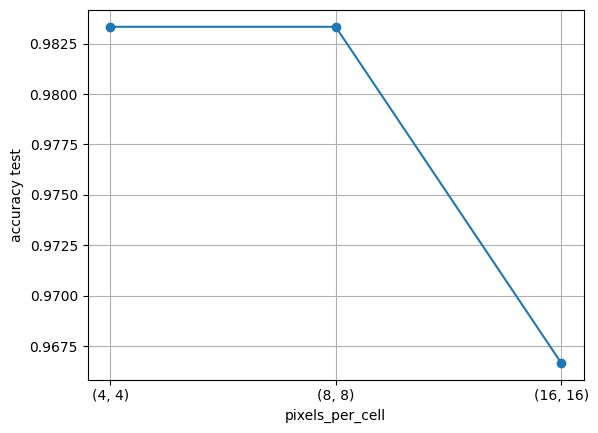

In [4]:
sizes = [(4, 4), (8, 8), (16, 16)]
scores = []
for s in sizes:
    X = np.array(
        [
            hog(im, orientations=9, pixels_per_cell=s, cells_per_block=(2, 2), block_norm="L2-Hys")
            for im in images
        ]
    )
    scores.append((s, X.shape[1], evaluate(X)))

for s, dim, acc in scores:
    print(f"pixels_per_cell={s}  dim={dim:5d}  acc={acc:.3f}")

plt.plot([str(s) for s, _, _ in scores], [acc for _, _, acc in scores], "o-")
plt.xlabel("pixels_per_cell")
plt.ylabel("accuracy test")
plt.grid(True)

**Discussion** : des cellules trop petites (4×4) explosent la dimension sans gain réel, tandis que des cellules trop grosses (16×16) perdent la finesse de la silhouette. Le réglage par défaut 8×8 est un bon compromis pour des visages 64×64.